In [1]:
# Sometimes it imports the pricer.py file from the src repository, restarting the kernel and running the cell again solved it for me.
import sys
from pathlib import Path

current_folder = str(Path().resolve())
if current_folder in sys.path:
    sys.path.remove(current_folder)

sys.path.insert(0, current_folder)

from pricer import *
%load_ext autoreload
%autoreload 2

import pricer
print(pricer.__file__)

MarketData.initialize()

QuantCourseBP 9ee54717d6c4f791ba27e5b72a9d17f9653292e3*
/Users/tothpatrik/QuantCourseBP/homeworks/9180744/my_homeworks/06_Assignment_MCMethods/pricer.py


In [2]:
und = Stock.BLUECHIP_BANK
spot = MarketData.get_spot()[und]
model = FlatVolModel(und)
strike = 1.1 * spot
expiry = 1.0

option = EuropeanContract(und, PutCallFwd.CALL, LongShort.LONG, strike, expiry)
an_pricer = EuropeanAnalyticPricer(option, model, Params())

mc_params = MCParams(num_of_path=10000,
                     tenor_frequency=4,
                     antithetic=False,
                     standardize=False,
                     control_variate=False,
                     seed=1,
                     evolve_spot_method=MCNumMethod.MILSTEIN)

mc_pricer = GenericMCPricer(option, model, mc_params)

fv_opt_an = an_pricer.calc_fair_value()
fv_opt_mc = mc_pricer.calc_fair_value_with_ci()

mc_pricer.params.evolve_spot_method = MCNumMethod.EULER
fv_opt_mc_e = mc_pricer.calc_fair_value_with_ci()

print("OPTION AN: " + str(fv_opt_an))
print("OPTION MC Milstein: " + str(fv_opt_mc))
print("OPTION MC Euler: " + str(fv_opt_mc_e))

OPTION AN: 17.50580599019625
OPTION MC Milstein: (17.073601898145473, (16.406765590305245, 17.740438205985697))
OPTION MC Euler: (17.192582576123286, (16.563492221905083, 17.82167293034149))


In [3]:
import copy
frequencies = [4, 12, 24, 52, 100, 200, 252]
dt_values = [expiry / f for f in frequencies]

error_euler = []
error_milstein = []

print(f"{'Tenor Freq':<12} | {'dt':<10} | {'Euler Error':<15} | {'Milstein Error':<15}")
print("-" * 55)

for freq, dt in zip(frequencies, dt_values):
    base_params = MCParams(
        num_of_path=10000,
        tenor_frequency=freq,
        antithetic=False,
        standardize=False,
        control_variate=False,
        seed=42)

    # exact paths
    params_exact = copy.deepcopy(base_params)
    params_exact.evolve_spot_method = MCNumMethod.EXACT
    mc_exact = MCMethodFlatVol(option, model, params_exact)
    terminal_exact = mc_exact.simulate_spot_paths()[:, -1] # we only need the last spot (which is in the final column)

    # euler paths
    params_euler = copy.deepcopy(base_params)
    params_euler.evolve_spot_method = MCNumMethod.EULER
    mc_euler = MCMethodFlatVol(option, model, params_euler)
    terminal_euler = mc_euler.simulate_spot_paths()[:, -1]

    # milstein paths
    params_milstein = copy.deepcopy(base_params)
    params_milstein.evolve_spot_method = MCNumMethod.MILSTEIN
    mc_milstein = MCMethodFlatVol(option, model, params_milstein)
    terminal_milstein = mc_milstein.simulate_spot_paths()[:, -1]

    # 4. Calculate the expected absolute pathwise errors
    err_e = np.mean(np.abs(terminal_euler - terminal_exact))
    err_m = np.mean(np.abs(terminal_milstein - terminal_exact))

    error_euler.append(err_e)
    error_milstein.append(err_m)

    print(f"{freq:<12} | {dt:<10.4f} | {err_e:<15.6f} | {err_m:<15.6f}")

Tenor Freq   | dt         | Euler Error     | Milstein Error 
-------------------------------------------------------
4            | 0.2500     | 5.492211        | 0.562460       
12           | 0.0833     | 3.268092        | 0.233756       
24           | 0.0417     | 2.329411        | 0.125636       
52           | 0.0192     | 1.585184        | 0.060848       
100          | 0.0100     | 1.126429        | 0.032428       
200          | 0.0050     | 0.796184        | 0.016221       
252          | 0.0040     | 0.710519        | 0.012982       


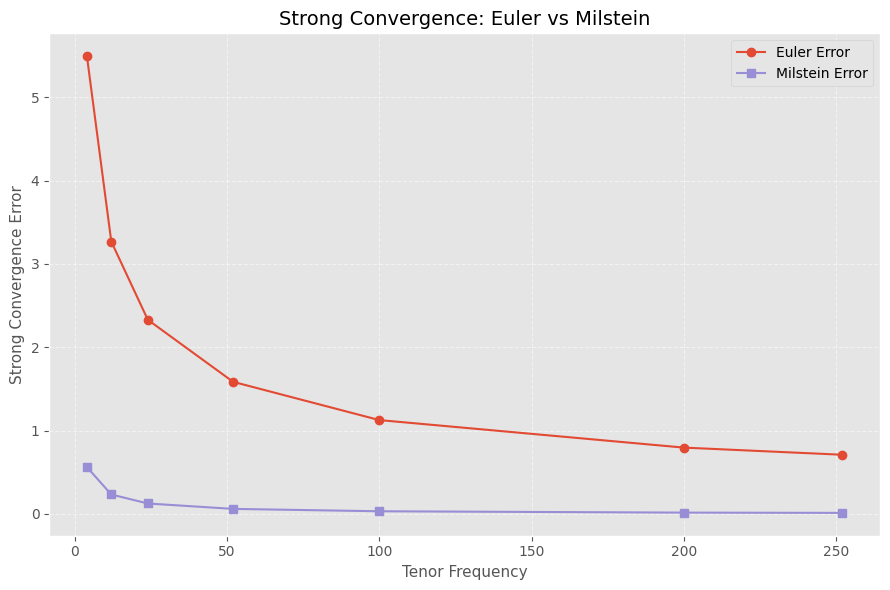

In [27]:
plt.figure(figsize=(9, 6))

plt.plot(frequencies, error_euler, marker='o', label='Euler Error', color='C0')
plt.plot(frequencies, error_milstein, marker='s', label='Milstein Error', color='C2')

plt.xlabel('Tenor Frequency', fontsize=11)
plt.ylabel('Strong Convergence Error', fontsize=11)
plt.title('Strong Convergence: Euler vs Milstein', fontsize=14)
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)

plt.style.use('ggplot')
plt.tight_layout()
plt.show()

We can see that Milstein error is smaller, but seemingly the Euler error is decreasing faster comparatively. Although that could just be the result of the length of the steps on the y- and x-axis.

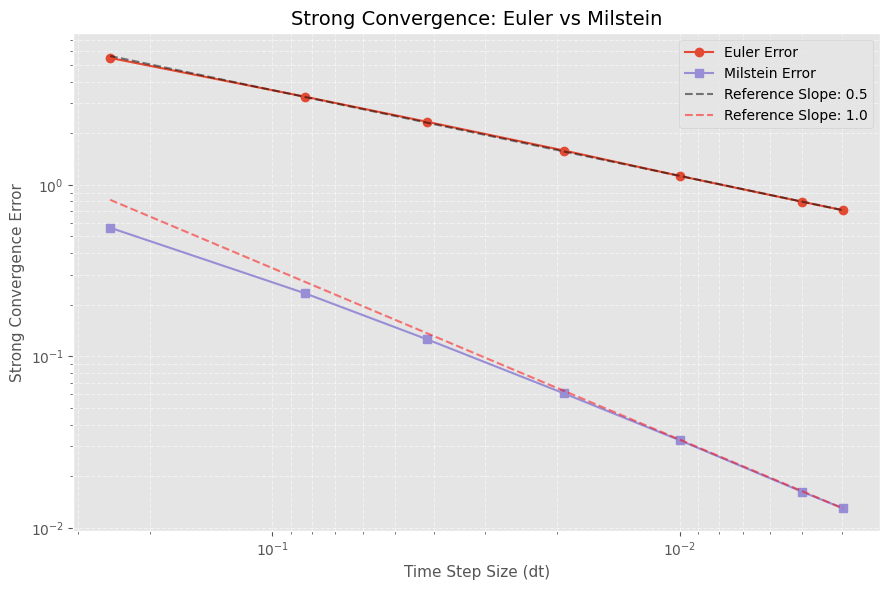

In [26]:
plt.figure(figsize=(9, 6))

plt.loglog(dt_values, error_euler, marker='o', label='Euler Error', color='C0')
plt.loglog(dt_values, error_milstein, marker='s', label='Milstein Error', color='C2')

# reference slopes for the errors to show that Milstein error is decreasing relatively faster with smaller dt step sizes compared to Euler error
ref_dt = np.array(dt_values)
plt.loglog(ref_dt, error_euler[-1] * (ref_dt / ref_dt[-1])**0.5, 'k--', alpha=0.5, label='Reference Slope: 0.5')
plt.loglog(ref_dt, error_milstein[-1] * (ref_dt / ref_dt[-1])**1.0, 'r--', alpha=0.5, label='Reference Slope: 1.0')

plt.xlabel('Time Step Size (dt)', fontsize=11)
plt.ylabel('Strong Convergence Error', fontsize=11)
plt.title('Strong Convergence: Euler vs Milstein', fontsize=14)
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.gca().invert_xaxis() # I invert the x axis to make the slopes of the lines negative

plt.style.use('ggplot')
plt.tight_layout()
plt.show()

When we look at our plots on a log-scale we can clearly see that Milstein error is not only smaller, but it also decreases faster with a slope of -1.0, while Euler decreases with a slope of -0.5. This is line with the order of strong convergence that we previously established for the Milstein and Euler methods.